# Hawaiian Airlines (HA) On-Time Performance Analysis
**Objective**: Analyze the relationship between daily flight volume, detailed fleet profiles (Producer, Variant, MSN), and departure punctuality, specifically isolated by **Origin Airport**.

---
### 1. Project Configuration & Setup
In this section, we define the global parameters and import the necessary libraries.

In [63]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# --- Global Settings ---
plt.style.use('ggplot')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# --- Configuration ---
BASE_DIR = os.getcwd()
CONFIG = {
    "DATA_DIR": os.path.join(BASE_DIR, 'bts_data'),
    "EXPORT_DIR": os.path.join(BASE_DIR, 'exports'),
    "FLEET_FILE": os.path.join(BASE_DIR, 'Hawaiian_Air_Fleet.csv'),
    "DELAY_THRESHOLD_MIN": 15,
    "INTER_ISLAND_HUBS": ['LNY', 'ITO', 'OGG', 'KOA', 'LIH', 'MKK', 'HNL']
}

# Ensure workspace directories exist
for path in [CONFIG['DATA_DIR'], CONFIG['EXPORT_DIR']]:
    os.makedirs(path, exist_ok=True)

print("Project structure initialized.")

Project structure initialized.


### 2. Data Transformation & Fleet Integration
We load the flight data and join it with a granular fleet profile. We also engineer temporal and route-based dimensions for ad-hoc slicing.

In [64]:
def load_and_clean_data(data_dir, hubs, threshold, fleet_file):
    """
    Loads BTS Detailed Statistics CSV files, cleans metadata headers, and merges with Aircraft Fleet profiles.
    """
    # 1. Load Granular Fleet Data
    fleet_df = pd.DataFrame()
    if os.path.exists(fleet_file):
        fleet_df = pd.read_csv(fleet_file)
        fleet_df = fleet_df.rename(columns={'Immatricul.': 'Tail Number', 'Serial': 'Variant', 'Nr.': 'MSN', 'Line Nr.': 'Line_Number'})
        fleet_df['Aircraft_Age'] = datetime.now().year - fleet_df['Year']
        # Use Variant as the Model Proxy
        fleet_df = fleet_df[['Tail Number', 'Producer', 'Variant', 'MSN', 'Line_Number', 'Aircraft_Age']]

    # 2. Load Flight Data
    files = glob.glob(os.path.join(data_dir, "Detailed_Statistics_Departures*.csv"))
    all_dfs = []
    delay_reason_cols = ['Delay Carrier (Minutes)', 'Delay Weather (Minutes)', 
                         'Delay National Aviation System (Minutes)', 'Delay Security (Minutes)', 
                         'Delay Late Aircraft Arrival (Minutes)']
    
    for f in files:
        try:
            df = pd.read_csv(f, skiprows=7, skipinitialspace=True)
            if df.empty: continue
            
            # Clean Dates
            date_col = 'Date (MM/DD/YYYY)'
            df = df.dropna(subset=[date_col])
            df['Date'] = pd.to_datetime(df[date_col], errors='coerce')
            df = df.dropna(subset=['Date'])
            
            # Extract Origin from Filename
            origin = os.path.basename(f).replace('.csv', '').split(' ')[-1]
            df['Origin'] = origin
            
            # Temporal Features
            df['DayOfWeek'] = df['Date'].dt.day_name()
            df['DepHour'] = pd.to_datetime(df['Scheduled departure time'], format='%H:%M', errors='coerce').dt.hour
            
            # Metrics & Delay Normalization
            df['Dep_Delay_Min'] = pd.to_numeric(df['Departure delay (Minutes)'].astype(str).str.replace(',', ''), errors='coerce').fillna(0)
            df['Punctuality'] = ['Late' if d > threshold else 'On-Time' for d in df['Dep_Delay_Min']]
            
            for col in delay_reason_cols:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce').fillna(0)
            
            all_dfs.append(df)
        except Exception as e: print(f"  [Error] {f}: {e}")
    
    combined_df = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
    
    # 3. Final Integration
    if not combined_df.empty and not fleet_df.empty:
        combined_df = pd.merge(combined_df, fleet_df, on='Tail Number', how='left')
    
    return combined_df

master_df = load_and_clean_data(CONFIG['DATA_DIR'], CONFIG['INTER_ISLAND_HUBS'], CONFIG['DELAY_THRESHOLD_MIN'], CONFIG['FLEET_FILE'])
if not master_df.empty: 
    print(f"Master Integration Complete: {len(master_df)} records.")

Master Integration Complete: 133283 records.


### 3. Ad-hoc Relationship: Flight Volume vs. OTP (By Origin Airport)
Testing hub sensitivity to daily traffic volume.

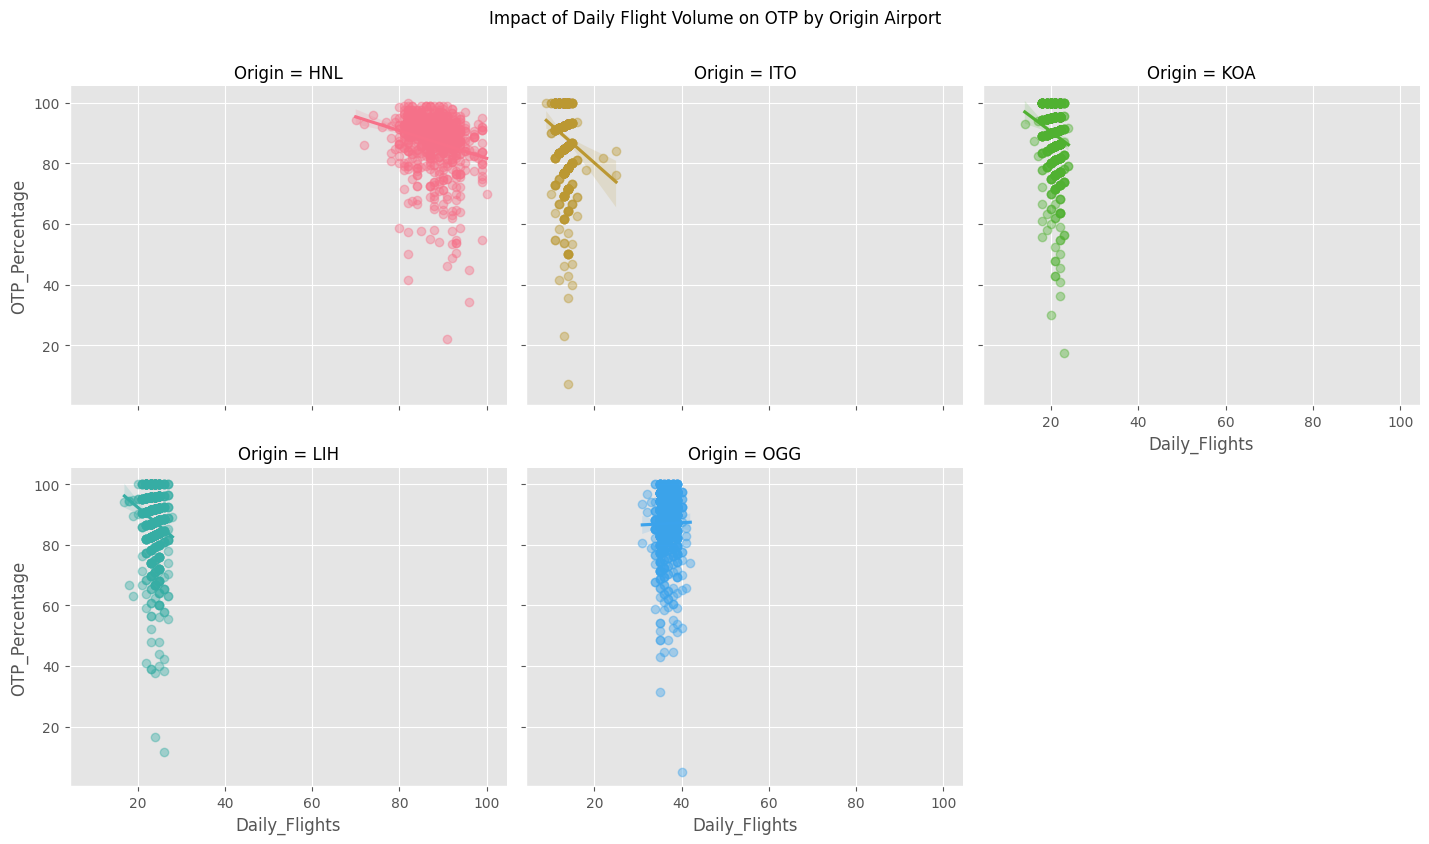

In [65]:
if not master_df.empty:
    daily_airport_stats = master_df.groupby(['Date', 'Origin']).agg(
        Daily_Flights=('Origin', 'count'),
        On_Time_Flights=('Punctuality', lambda x: (x == 'On-Time').sum())
    ).reset_index()
    daily_airport_stats['OTP_Percentage'] = (daily_airport_stats['On_Time_Flights'] / daily_airport_stats['Daily_Flights']) * 100

    g = sns.lmplot(data=daily_airport_stats, x='Daily_Flights', y='OTP_Percentage', col='Origin', hue='Origin', col_wrap=3, height=4, aspect=1.2, scatter_kws={'alpha':0.4})
    g.fig.suptitle('Impact of Daily Flight Volume on OTP by Origin Airport', y=1.05)
    plt.show()

### 4. Operational Deep Dive: Delay Reasons by Airport
Identifying the specific root causes of delays isolated by departure airport.

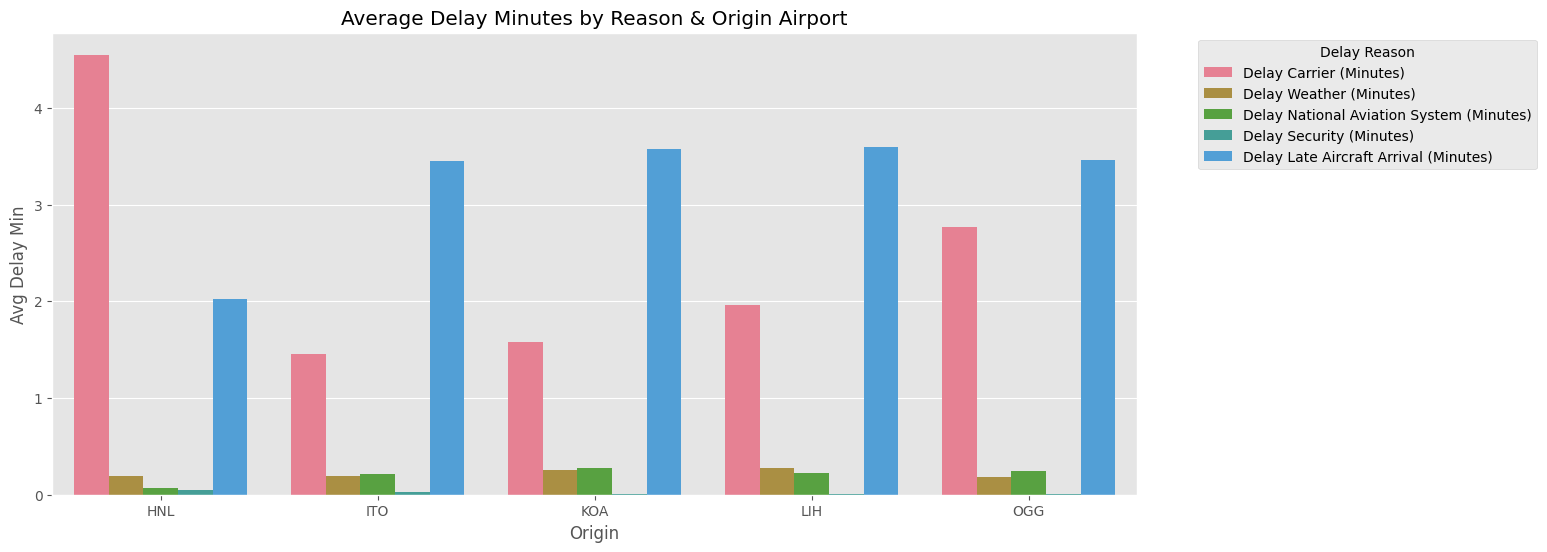

In [66]:
if not master_df.empty:
    delay_cols = ['Delay Carrier (Minutes)', 'Delay Weather (Minutes)', 
                  'Delay National Aviation System (Minutes)', 'Delay Security (Minutes)', 
                  'Delay Late Aircraft Arrival (Minutes)']
    airport_issues = master_df.groupby('Origin')[delay_cols].mean().melt(ignore_index=False).reset_index()
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data=airport_issues, x='Origin', y='value', hue='variable')
    plt.title('Average Delay Minutes by Reason & Origin Airport')
    plt.ylabel('Avg Delay Min')
    plt.legend(title='Delay Reason', bbox_to_anchor=(1.05, 1))
    plt.show()

### 5. Route Performance Heatmap
Mapping every Origin-Destination pair to its On-Time Performance percentage.

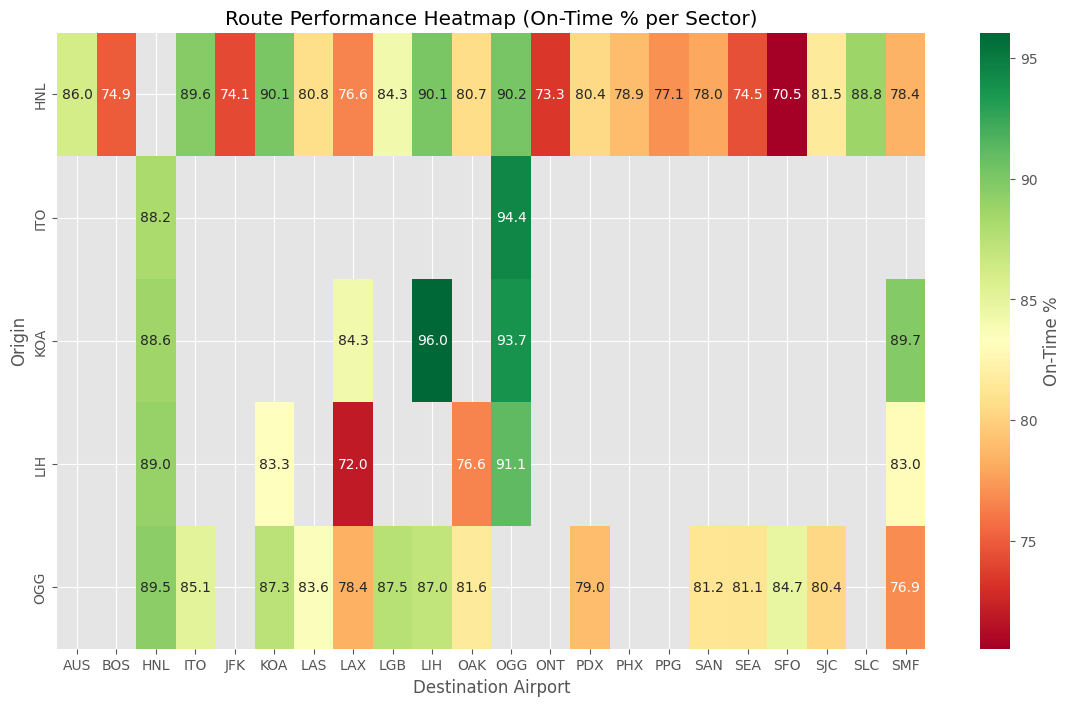

In [67]:
if not master_df.empty:
    route_matrix = master_df.groupby(['Origin', 'Destination Airport'])['Punctuality'].apply(lambda x: (x == 'On-Time').mean() * 100).unstack()
    plt.figure(figsize=(14, 8))
    sns.heatmap(route_matrix, annot=True, fmt=".1f", cmap='RdYlGn', cbar_kws={'label': 'On-Time %'})
    plt.title('Route Performance Heatmap (On-Time % per Sector)')
    plt.show()

### 6. Ad-hoc Slicing: Temporal Patterns by Airport
Analyzing hourly and daily performance trends across different hubs.

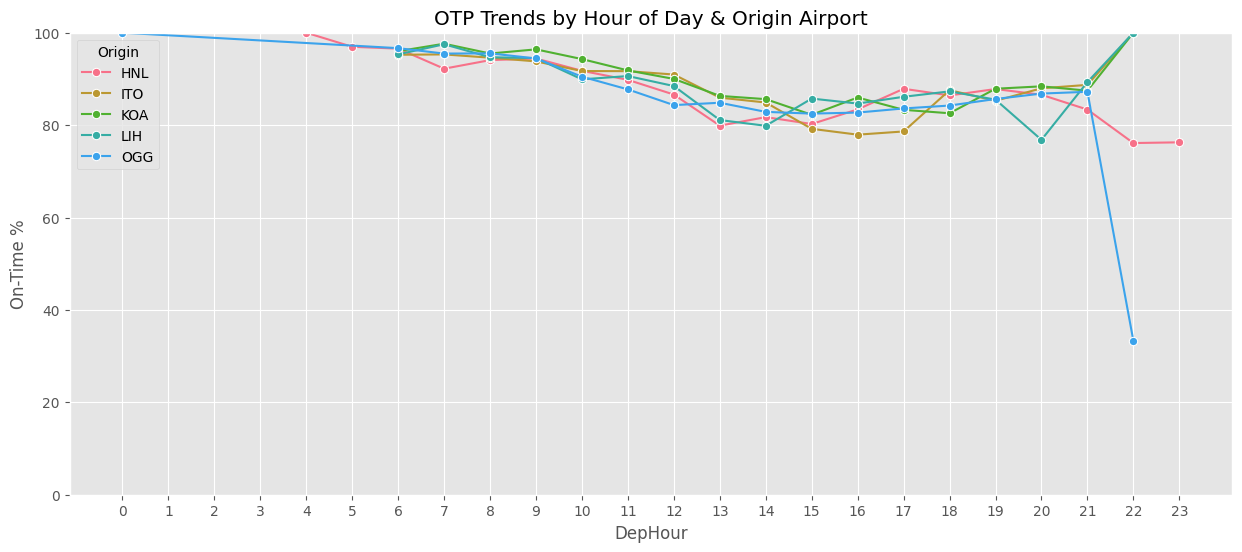

In [68]:
if not master_df.empty:
    # 1. Performance by Departure Hour faceted by Origin
    hour_ap_perf = master_df.groupby(['Origin', 'DepHour'])['Punctuality'].apply(lambda x: (x == 'On-Time').mean() * 100).reset_index()
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=hour_ap_perf, x='DepHour', y='Punctuality', hue='Origin', marker='o')
    plt.title('OTP Trends by Hour of Day & Origin Airport')
    plt.ylabel('On-Time %')
    plt.xticks(range(0, 24))
    plt.ylim(0, 100)
    plt.grid(True)
    plt.show()

### 7. Ad-hoc Slicing: Fleet Reliability (Model & Age vs. OTP)
In this section, we analyze if specific aircraft models or older airframes are less reliable, impacting overall network performance.

C:\Users\Ned\AppData\Local\Temp\ipykernel_17012\1692849995.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_otp, x='Punctuality', y='Variant', palette='viridis')


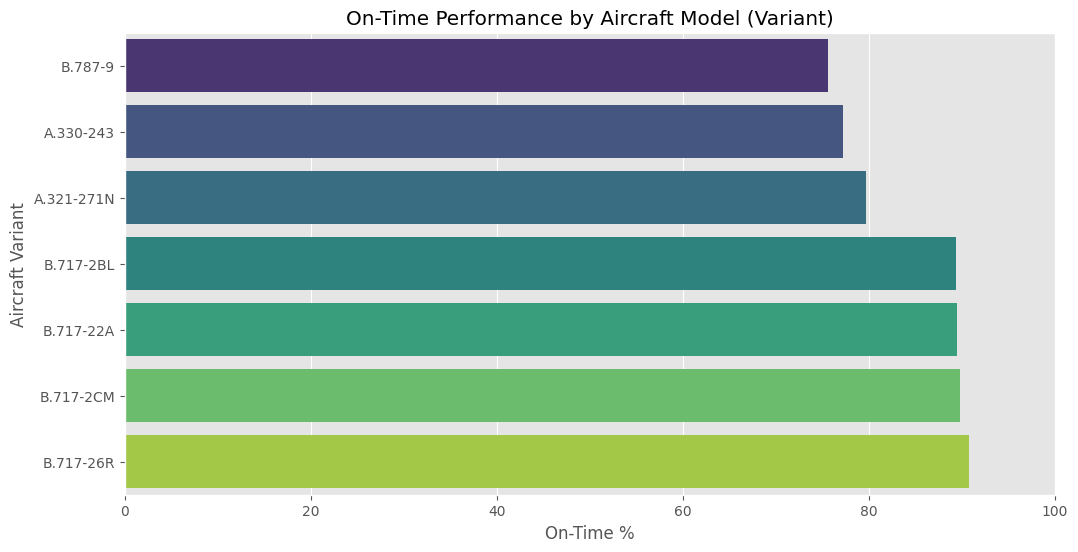

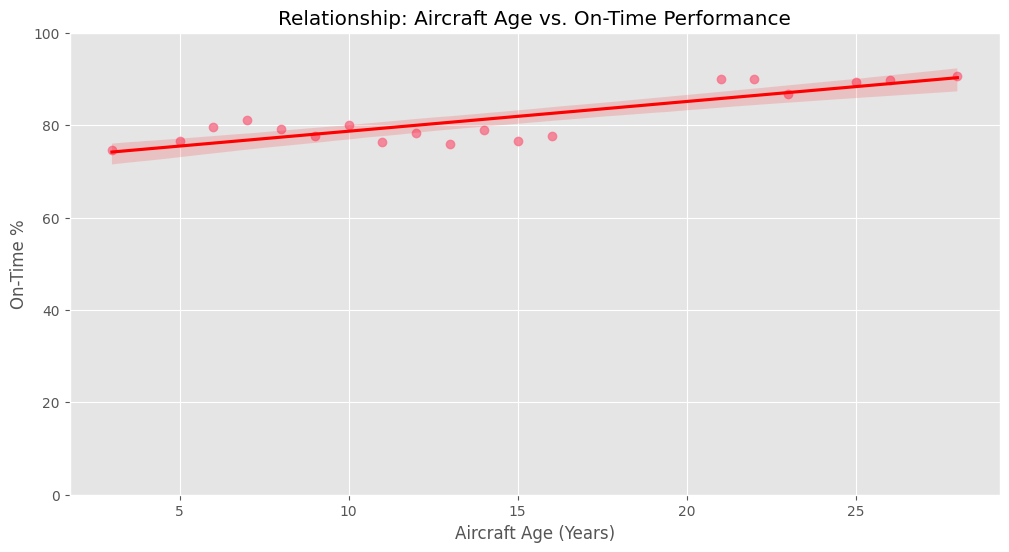


--- Fleet Insight Summary ---
Correlation between Aircraft Age and OTP: 0.85
Note: A negative correlation would suggest that older aircraft are harder to keep on-time.


In [69]:
if not master_df.empty and 'Variant' in master_df.columns:
    # 1. OTP by Aircraft Model (Variant)
    model_otp = master_df.groupby('Variant')['Punctuality'].apply(lambda x: (x == 'On-Time').mean() * 100).sort_values().reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=model_otp, x='Punctuality', y='Variant', palette='viridis')
    plt.title('On-Time Performance by Aircraft Model (Variant)')
    plt.xlabel('On-Time %')
    plt.ylabel('Aircraft Variant')
    plt.xlim(0, 100)
    plt.show()

    # 2. Relationship: Aircraft Age vs. OTP
    # Mechanism: We aggregate by aircraft age to see if there's a trend in punctuality as airframes get older.
    age_perf = master_df.groupby('Aircraft_Age')['Punctuality'].apply(lambda x: (x == 'On-Time').mean() * 100).reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.regplot(data=age_perf, x='Aircraft_Age', y='Punctuality', line_kws={'color': 'red'})
    plt.title('Relationship: Aircraft Age vs. On-Time Performance')
    plt.xlabel('Aircraft Age (Years)')
    plt.ylabel('On-Time %')
    plt.ylim(0, 100)
    plt.grid(True)
    plt.show()
    
    print("\n--- Fleet Insight Summary ---")
    age_corr = age_perf['Aircraft_Age'].corr(age_perf['Punctuality'])
    print(f"Correlation between Aircraft Age and OTP: {age_corr:.2f}")
    print("Note: A negative correlation would suggest that older aircraft are harder to keep on-time.")
else:
    print("Fleet metadata not available for this analysis.")

### 8. Final Export
Saving the hub and fleet granular analytical dataset.

In [70]:
if not master_df.empty:
    output_path = os.path.join(CONFIG['EXPORT_DIR'], 'HA_Comprehensive_Analysis_Master.csv')
    master_df.to_csv(output_path, index=False)
    print(f"Comprehensive analytical file exported to: {output_path}")

Comprehensive analytical file exported to: c:\Python\GitHub\Airlines Performance Analysis\exports\HA_Comprehensive_Analysis_Master.csv
